In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "setup.py").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Project root not found. Run this notebook from inside the repository.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.model_classes import SimpleTransformer
from utils.embedding_transformer_utils import (
    get_torch_device,
    load_simple_transformer_model,
    sample_dataframe,
    set_torch_seed,
)

print(f"Project root: {PROJECT_ROOT}")

GRAPH_FEATURES_PATH = PROJECT_ROOT / "data" / "graph_features"
TRAIN_PATH = GRAPH_FEATURES_PATH / "train.parquet"
VAL_PATH = GRAPH_FEATURES_PATH / "val.parquet"
TEST_PATH = GRAPH_FEATURES_PATH / "test.parquet"

RANDOM_STATE = 42
DEVICE = get_torch_device()
print(f"Using device: {DEVICE}")
print(f"Graph features: {GRAPH_FEATURES_PATH}")


Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Using device: cuda
Graph features: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/graph_features


# Simple Transformer Model - on graph features

This notebook trains a lightweight Transformer on graph-based citation features. Instead of using textual embeddings, each scalar graph feature is treated as a token: the model learns feature embeddings, applies a Transformer encoder, and predicts whether a citation pair is valid.

The implementation follows the shared model interface used in the rest of the project:

- `BaseModel`: common contract for preprocessing, training, prediction, evaluation, and saving.
- `SimpleTransformer`: PyTorch wrapper for graph features. It scales numeric graph columns with `RobustScaler`, supports optional validation during training, exposes `predict` / `predict_proba`, and saves a reloadable checkpoint.


## 1. Load graph feature data


In [4]:
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

ID_COLUMNS = ["article_id", "ref_id"]
df_train = df_train.drop(columns=ID_COLUMNS, errors="ignore")
df_val = df_val.drop(columns=ID_COLUMNS, errors="ignore")
df_test = df_test.drop(columns=ID_COLUMNS, errors="ignore")

NON_FEATURE_COLS = {
    "is_reference_valid",
    "article_id",
    "ref_id",
    "vector_text_article",
    "vector_text_ref",
    "split",
}
GRAPH_FEATURE_COLS = [
    col
    for col in df_train.drop(columns=list(NON_FEATURE_COLS), errors="ignore").select_dtypes(include=[np.number, "bool"]).columns
]

print("Split sizes:", {"train": len(df_train), "val": len(df_val), "test": len(df_test)})
print(f"Graph feature columns ({len(GRAPH_FEATURE_COLS)}):")
print(GRAPH_FEATURE_COLS)


Split sizes: {'train': 2162520, 'val': 391242, 'test': 396382}
Graph feature columns (15):
['in_article', 'out_article', 'pagerank_article', 'avg_neigh_degree_article', 'katz_cent_article', 'in_ref', 'out_ref', 'pagerank_ref', 'avg_neigh_degree_ref', 'katz_cent_ref', 'degree_ratio', 'pagerank_ratio', 'pagerank_prod', 'common_neighbors', 'jaccard_coeff']


In [5]:
set_torch_seed(RANDOM_STATE)

# Use None to train/evaluate on the full split. Set an integer for faster notebook experiments.
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None

TRAINING_PARAMS = {
    "epochs": 15,
    "batch_size": 512,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "patience": 5,
}

MODEL_PARAMS = {
    "num_features": len(GRAPH_FEATURE_COLS),
    "d_model": 64,
    "nhead": 8,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout": 0.15,
}

df_train_model = sample_dataframe(df_train, MAX_TRAIN_SAMPLES, RANDOM_STATE)
df_val_model = sample_dataframe(df_val, MAX_VAL_SAMPLES, RANDOM_STATE)
df_test_model = sample_dataframe(df_test, MAX_TEST_SAMPLES, RANDOM_STATE)

print("Model split sizes:", {"train": len(df_train_model), "val": len(df_val_model), "test": len(df_test_model)})


Model split sizes: {'train': 2162520, 'val': 391242, 'test': 396382}


## 2. Train the SimpleTransformer


[SimpleTransformer_graph] Preprocessing 2162520 rows...


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Label distribution:
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64
[SimpleTransformer_graph] Starting training...


epoch 1 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

...

epoch 7 train:   0%|          | 0/4224 [00:00<?, ?it/s]

predict:   0%|          | 0/765 [00:00<?, ?it/s]

{'epoch': 7, 'train_loss': 0.18760059095138146, 'val_f1_weighted': 0.8141030591135671}
Early stopping at epoch 7


predict:   0%|          | 0/4224 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.8955    0.8774    0.8864   1081260
           1     0.8798    0.8976    0.8886   1081260

    accuracy                         0.8875   2162520
   macro avg     0.8877    0.8875    0.8875   2162520
weighted avg     0.8877    0.8875    0.8875   2162520



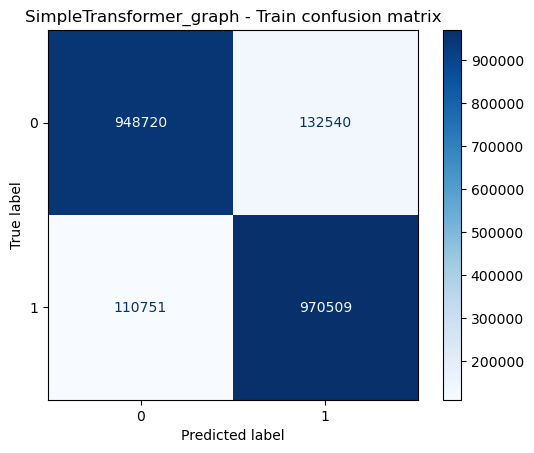

{'accuracy': 0.8874965318239831,
 'f1_weighted': 0.8874851092406482,
 'precision_weighted': 0.8876539513276351,
 'recall_weighted': 0.8874965318239831}

In [6]:
simple_transformer = SimpleTransformer(
    model_name="SimpleTransformer_graph",
    device=DEVICE,
    feature_cols=GRAPH_FEATURE_COLS,
    **MODEL_PARAMS,
)

train_metrics = simple_transformer.train_pipeline(
    df_train_model,
    raw_val=df_val_model,
    **TRAINING_PARAMS,
)
train_metrics


> The confusion matrix show an accuracy of 93.94%. The model seems like to be pretty balance, with similar quantities of true values,, and small number of errors, with a shift over false positives values. Overall the model seems to have capture the pattern of the data.

predict:   0%|          | 0/765 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.9528    0.7871    0.8620    195621
           1     0.8186    0.9610    0.8841    195621

    accuracy                         0.8740    391242
   macro avg     0.8857    0.8740    0.8731    391242
weighted avg     0.8857    0.8740    0.8731    391242



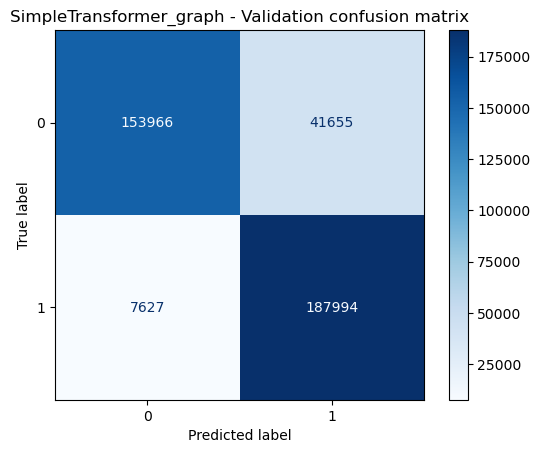

{'accuracy': 0.8740370410129792,
 'f1_weighted': 0.8730769277177556,
 'precision_weighted': 0.8857078338058082,
 'recall_weighted': 0.8740370410129792}

In [7]:
X_val, y_val = simple_transformer.preprocess(df_val_model, is_training=False, verbose=False)
y_val_pred = simple_transformer.predict(X_val, batch_size=TRAINING_PARAMS["batch_size"])
validation_metrics = simple_transformer.evaluate(
    y_val,
    y_val_pred,
    title="SimpleTransformer_graph - Validation confusion matrix",
)
validation_metrics


> The results shows a slightly decrease in the accuracy (88.88%), with the model that is more capable of identifying valid references than invalid ones. As saw before, there are major cases of false positives than false negatives that need to be corrected.

## 3. Training notes

The validation split is passed directly to `train_pipeline`, so early stopping monitors weighted F1 on held-out data while keeping the scaler fitted only on the training split. The model can be trained on the full graph-feature dataset or on deterministic samples by changing the `MAX_*_SAMPLES` values above.


## 4. Optional hyperparameter experiments

`SimpleTransformer` is a PyTorch model, so the notebook uses a small manual experiment loop instead of `GridSearchCV`. Keep `RUN_HYPERPARAM_EXPERIMENTS = False` for a single final run, or enable it to compare a few compact configurations on the current train/validation samples.


In [8]:
RUN_HYPERPARAM_EXPERIMENTS = False

candidate_configs = [
    {"d_model": 32, "nhead": 4, "num_layers": 1, "dim_feedforward": 64, "dropout": 0.10},
    {"d_model": 64, "nhead": 4, "num_layers": 2, "dim_feedforward": 128, "dropout": 0.15},
    {"d_model": 128, "nhead": 8, "num_layers": 2, "dim_feedforward": 256, "dropout": 0.20},
]

experiment_results = []
best_model = None
best_score = -np.inf

if RUN_HYPERPARAM_EXPERIMENTS:
    for idx, config in enumerate(candidate_configs, start=1):
        set_torch_seed(RANDOM_STATE + idx)
        params = {"num_features": len(GRAPH_FEATURE_COLS), **config}
        candidate_model = SimpleTransformer(
            model_name=f"SimpleTransformer_graph_exp_{idx}",
            device=DEVICE,
            feature_cols=GRAPH_FEATURE_COLS,
            **params,
        )
        candidate_model.train_pipeline(df_train_model, raw_val=df_val_model, **TRAINING_PARAMS)

        X_val_exp, y_val_exp = candidate_model.preprocess(df_val_model, is_training=False, verbose=False)
        y_val_exp_pred = candidate_model.predict(X_val_exp, batch_size=TRAINING_PARAMS["batch_size"])
        metrics = candidate_model.evaluate(
            y_val_exp,
            y_val_exp_pred,
            title=f"SimpleTransformer_graph_exp_{idx} - Validation confusion matrix",
        )
        row = {"experiment": idx, **params, **metrics}
        experiment_results.append(row)

        if metrics["f1_weighted"] > best_score:
            best_score = metrics["f1_weighted"]
            best_model = candidate_model

    experiment_results = pd.DataFrame(experiment_results).sort_values("f1_weighted", ascending=False)
    display(experiment_results)
else:
    print("Set RUN_HYPERPARAM_EXPERIMENTS = True to run the comparison loop.")


Set RUN_HYPERPARAM_EXPERIMENTS = True to run the comparison loop.


## 5. Final evaluation on the test split

The final model is the best model from the optional experiment loop when that loop is enabled. Otherwise, it is the single `simple_transformer` trained above.


[SimpleTransformer_graph] Preprocessing 396382 rows...
Label distribution:
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


predict:   0%|          | 0/775 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0     0.9303    0.8264    0.8753    198191
           1     0.8438    0.9381    0.8885    198191

    accuracy                         0.8822    396382
   macro avg     0.8871    0.8822    0.8819    396382
weighted avg     0.8871    0.8822    0.8819    396382



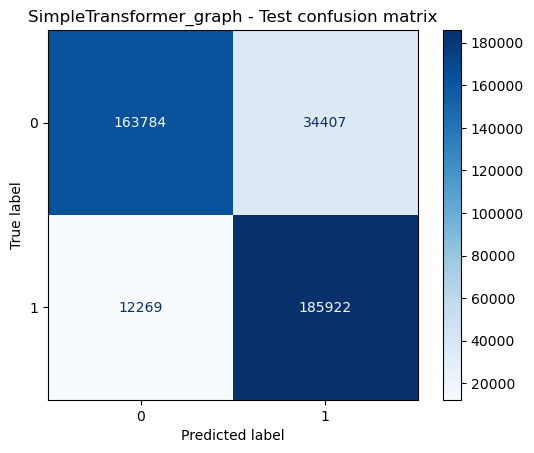

{'accuracy': 0.8822449051672376,
 'f1_weighted': 0.8818764493566412,
 'precision_weighted': 0.8870744186009247,
 'recall_weighted': 0.8822449051672376}

In [9]:
final_transformer = best_model if best_model is not None else simple_transformer

test_metrics = final_transformer.test_pipeline(
    df_test_model,
    batch_size=TRAINING_PARAMS["batch_size"],
)
test_metrics


> After an exhaustive hyperparameters tuning, the accuracy slightly increased, but the model still suffer of imbalance, with a number of false positives similar to the models performances before the tuning.

## 6. Save and reload the trained model

The model is saved as a PyTorch checkpoint together with its scaler, selected feature columns, threshold, training history, and metadata summary. The reload helper restores the full wrapper so it can be used again with `preprocess`, `predict`, and `test_pipeline`.


In [10]:
from utils.model_saver import save_model_artifact
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

save_model_artifact(final_transformer, df_name='graph_features', 
                    model_name="Transformer_graph", 
                    relative_model_dir=MODEL_SAVE_PATH)

In [11]:
# loaded_transformer = load_simple_transformer_model(
#     model_path,
#     model_name=final_transformer.model_name,
#     device=DEVICE,
# )

# print("Model checkpoint:", model_path)
# print("Summary:", summary_path)
# print("Reloaded feature columns:", len(loaded_transformer.feature_cols))